# Tarea: Árboles de Decisión para Clasificación
## Clasificación con Decision Tree usando Gini Index y Entropy

**Nombre:** Scarlett Cedeño  
**Fecha:** 28/06/2026  

### Objetivo:
Familiarizar al estudiante con los Árboles de Decisión para clasificación, implementando modelos con diferentes criterios de división (Gini Index y Entropy), analizando el efecto de los hiperparámetros como `max_depth` en el rendimiento del modelo, y comparando los resultados mediante métricas de evaluación y visualización del árbol.

### Instrucciones:
1. Ejecute cada celda de código en orden.
2. **En las celdas de código marcadas con '# TODO:', implemente el código requerido siguiendo las instrucciones.**
3. Ejecute las celdas implementadas y responda las preguntas de selección múltiple.
4. Marque sus respuestas claramente.
5. Experimente modificando hiperparámetros cuando se indique.

### Descripción del Dataset:
Utilizaremos el **Car Evaluation Dataset** del UCI Machine Learning Repository. Este dataset contiene información sobre evaluación de automóviles basada en 6 atributos:
- **buying**: Precio de compra (vhigh, high, med, low)
- **maint**: Costo de mantenimiento (vhigh, high, med, low)
- **doors**: Número de puertas (2, 3, 4, 5more)
- **persons**: Capacidad de personas (2, 4, more)
- **lug_boot**: Tamaño del maletero (small, med, big)
- **safety**: Seguridad estimada (low, med, high)

**Variable objetivo (class):** Evaluación del auto (unacc, acc, good, vgood)

### Archivo requerido:
- `car.data` - Dataset de evaluación de automóviles

## Parte 1: Configuración y Carga de Datos

In [1]:
# Importar librerias necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configuracion para gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

In [7]:
# Definimos los nombres de columnas segun el repositorio UCI
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

# Cargamos el archivo sin encabezado y asignamos los nombres de columna
df = pd.read_csv('car.data', header=None, names=col_names)

print('Dimensiones del dataset: ', df.shape)
df.head()

Dimensiones del dataset:  (1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


### Pregunta 1: Dimensiones del Dataset
¿Cuántas muestras y características tiene el dataset?

A) 1728 muestras, 6 características  
B) 1728 muestras, 7 características  
C) 1000 muestras, 6 características  
D) 2000 muestras, 7 características  

**Su Respuesta:** A

## Parte 2: Análisis Exploratorio de Datos (EDA)

In [8]:
# Tipos de datos y conteo de valores no nulos por columna
df.info()

# Estadisticas descriptivas generales
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [9]:
# Valores unicos de cada columna para entender el dominio de cada variable
for col in df.columns:
    print(f'{col}: {df[col].unique()}')

buying: ['vhigh' 'high' 'med' 'low']
maint: ['vhigh' 'high' 'med' 'low']
doors: ['2' '3' '4' '5more']
persons: ['2' '4' 'more']
lug_boot: ['small' 'med' 'big']
safety: ['low' 'med' 'high']
class: ['unacc' 'acc' 'vgood' 'good']


In [10]:
# Verificamos si existe algun valor nulo en el dataset
print('Valores nulos por columna:')
print(df.isnull().sum())
print('\nTotal de valores nulos:', df.isnull().sum().sum())

Valores nulos por columna:
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

Total de valores nulos: 0


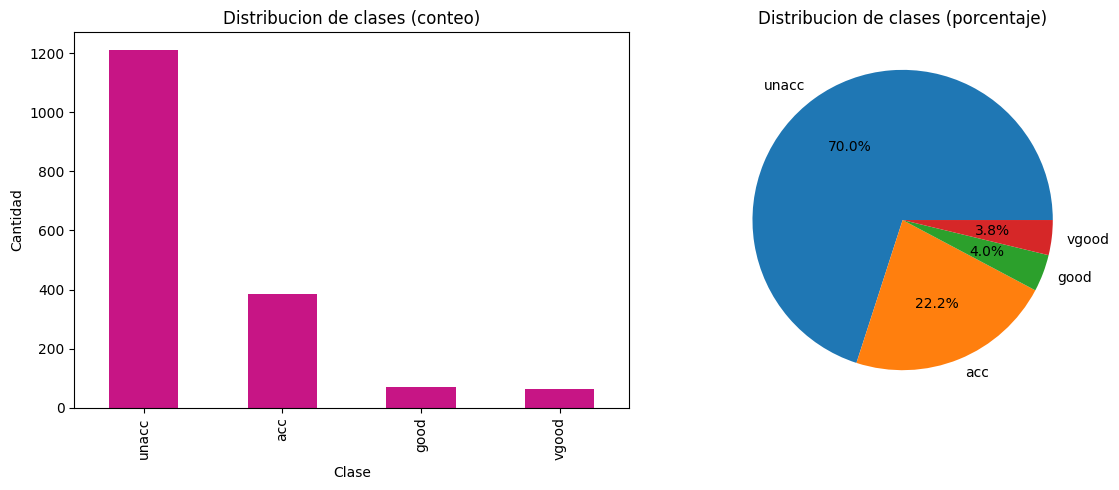


Conteo por clase:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafico de barras: conteo absoluto por clase
df['class'].value_counts().plot(kind='bar', ax=axes[0], color='mediumvioletred')
axes[0].set_title('Distribucion de clases (conteo)')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad')

# Grafico de torta: proporcion porcentual por clase
df['class'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Distribucion de clases (porcentaje)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('\nConteo por clase:')
print(df['class'].value_counts())


### Pregunta 2: Distribución de Clases
¿Cuál es la clase más frecuente en el dataset?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** C

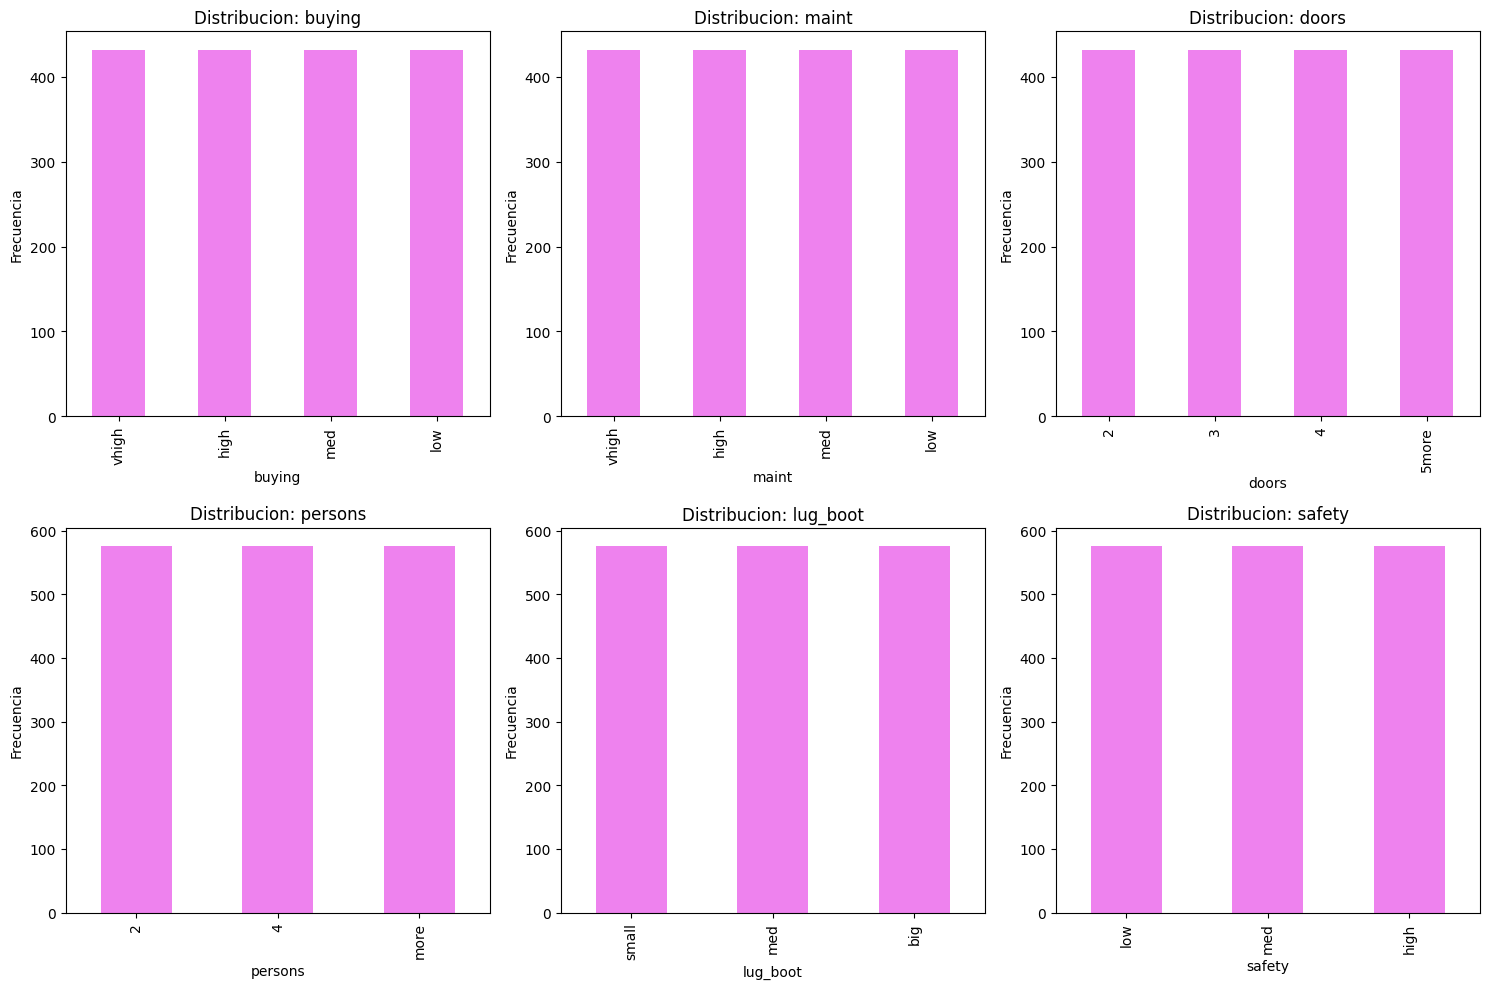

In [15]:
features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Graficamos la distribucion de cada caracteristica categorica
for ax, feature in zip(axes.flatten(), features):
    df[feature].value_counts().plot(kind='bar', ax=ax, color='violet')
    ax.set_title(f'Distribucion: {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Pregunta 3: Balance del Dataset
¿El dataset está balanceado respecto a la variable objetivo?

A) Sí, todas las clases tienen la misma frecuencia  
B) No, hay un fuerte desbalance (unacc es la mayoritaria con >70%)  
C) No, pero el desbalance es leve  
D) No se puede determinar  

**Su Respuesta:** B

## Parte 3: Preprocesamiento - Label Encoding

### Teoría:
Los árboles de decisión en Scikit-Learn requieren que las variables categóricas sean convertidas a valores numéricos. Usaremos **Label Encoding** para transformar cada categoría en un número entero.

In [19]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
label_encoders = {}

# Aplicamos LabelEncoder a cada columna categorica
# Cada encoder se guarda para poder recuperar las etiquetas originales
for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print('Dataset codificado:')
df_encoded.head()

Dataset codificado:


,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [20]:
# Mostramos la correspondencia entre valores originales y su codigo numerico
for col, le in label_encoders.items():
    mapeo = dict(zip(le.classes_, range(len(le.classes_))))
    print(f'{col}: {mapeo}')

buying: {'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}
maint: {'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}
doors: {'2': 0, '3': 1, '4': 2, '5more': 3}
persons: {'2': 0, '4': 1, 'more': 2}
lug_boot: {'big': 0, 'med': 1, 'small': 2}
safety: {'high': 0, 'low': 1, 'med': 2}
class: {'acc': 0, 'good': 1, 'unacc': 2, 'vgood': 3}


### Pregunta 4: Label Encoding
¿Qué hace Label Encoding?

A) Elimina las variables categóricas  
B) Convierte categorías a valores numéricos enteros  
C) Normaliza los datos entre 0 y 1  
D) Crea variables dummy (one-hot encoding)  

**Su Respuesta:** B

## Parte 4: División de Datos

In [21]:
# Separamos las caracteristicas de entrada (X) de la variable objetivo (y)
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

print('Forma de X:', X.shape)
print('Forma de y:', y.shape)
print('Caracteristicas:', list(X.columns))

Forma de X: (1728, 6)
Forma de y: (1728,)
Caracteristicas: ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']


In [22]:
# Dividimos en entrenamiento (67%) y prueba (33%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=19
)

print('Tamano X_train:', X_train.shape)
print('Tamano X_test:', X_test.shape)
print('Tamano y_train:', y_train.shape)
print('Tamano y_test:', y_test.shape)


Tamano X_train: (1157, 6)
Tamano X_test: (571, 6)
Tamano y_train: (1157,)
Tamano y_test: (571,)


### Pregunta 5: División de Datos
Con test_size=0.33, ¿cuál es aproximadamente el tamaño del conjunto de entrenamiento?

A) 570 muestras  
B) 1157 muestras  
C) 1728 muestras  
D) 864 muestras  

**Su Respuesta:** B

## Parte 5: Árbol de Decisión con Criterio Gini Index

### Teoría - Gini Index:
El índice Gini mide la impureza de un nodo. Se calcula como:

$$Gini = 1 - \sum_{i=1}^{n} p_i^2$$

Donde $p_i$ es la probabilidad de la clase $i$ en el nodo. Un Gini de 0 indica pureza perfecta.

In [23]:
# Creamos el arbol de decision con criterio Gini e impureza maxima
# max_depth=3 limita la profundidad para evitar sobreajuste
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=19)
clf_gini.fit(X_train, y_train)

print('Profundidad del arbol:', clf_gini.get_depth())
print('Numero de hojas:', clf_gini.get_n_leaves())

Profundidad del arbol: 3
Numero de hojas: 5


In [24]:
# Evaluamos el modelo Gini en entrenamiento y prueba
y_pred_gini = clf_gini.predict(X_test)
y_pred_gini_train = clf_gini.predict(X_train)

acc_gini_test  = accuracy_score(y_test, y_pred_gini)
acc_gini_train = accuracy_score(y_train, y_pred_gini_train)

print(f'Precision en entrenamiento (Gini): {acc_gini_train:.4f}')
print(f'Precision en prueba       (Gini): {acc_gini_test:.4f}')

Precision en entrenamiento (Gini): 0.7874
Precision en prueba       (Gini): 0.7653


### Pregunta 6: Precisión con Gini (max_depth=3)
¿Cuál es la precisión aproximada del modelo con Gini Index y max_depth=3?

A) 60-70%  
B) 70-80%  
C) 80-90%  
D) 90-100%  

**Su Respuesta:** B

## Parte 6: Árbol de Decisión con Criterio Entropy

### Teoría - Entropy (Information Gain):
La entropía mide el desorden o incertidumbre. Se calcula como:

$$Entropy = -\sum_{i=1}^{n} p_i \log_2(p_i)$$

El **Information Gain** es la reducción de entropía después de una división.

In [25]:
# Creamos el arbol con criterio Entropy (Ganancia de Informacion)
clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=19)
clf_entropy.fit(X_train, y_train)

print('Profundidad del arbol:', clf_entropy.get_depth())
print('Numero de hojas:', clf_entropy.get_n_leaves())

Profundidad del arbol: 3
Numero de hojas: 5


In [26]:
# Evaluamos el modelo Entropy en entrenamiento y prueba
y_pred_entropy = clf_entropy.predict(X_test)
y_pred_entropy_train = clf_entropy.predict(X_train)

acc_entropy_test  = accuracy_score(y_test, y_pred_entropy)
acc_entropy_train = accuracy_score(y_train, y_pred_entropy_train)

print(f'Precision en entrenamiento (Entropy): {acc_entropy_train:.4f}')
print(f'Precision en prueba       (Entropy): {acc_entropy_test:.4f}')

Precision en entrenamiento (Entropy): 0.7874
Precision en prueba       (Entropy): 0.7653


### Pregunta 7: Comparación Gini vs Entropy
Con max_depth=3, ¿qué criterio obtiene mejor precisión?

A) Gini es significativamente mejor  
B) Entropy es significativamente mejor  
C) Ambos obtienen resultados muy similares  
D) No se puede comparar  

**Su Respuesta:** C

## Parte 7: Comparación de Modelos

In [27]:
# Tabla comparativa entre los dos criterios con las mismas condiciones
comparacion = pd.DataFrame({
    'Criterio'         : ['Gini Index', 'Entropy'],
    'Precision Train'  : [acc_gini_train, acc_entropy_train],
    'Precision Test'   : [acc_gini_test,  acc_entropy_test],
    'Profundidad'      : [clf_gini.get_depth(),    clf_entropy.get_depth()],
    'Hojas'            : [clf_gini.get_n_leaves(), clf_entropy.get_n_leaves()]
})

print(comparacion)

     Criterio  Precision Train  Precision Test  Profundidad  Hojas
0  Gini Index         0.787381        0.765324            3      5
1     Entropy         0.787381        0.765324            3      5


### Pregunta 8: Sobreajuste
Si la precisión en entrenamiento es mucho mayor que en prueba, ¿qué indica?

A) Subajuste (underfitting)  
B) Sobreajuste (overfitting)  
C) El modelo está bien ajustado  
D) Los datos son incorrectos  

**Su Respuesta:** B

## Parte 8: Matriz de Confusión y Métricas

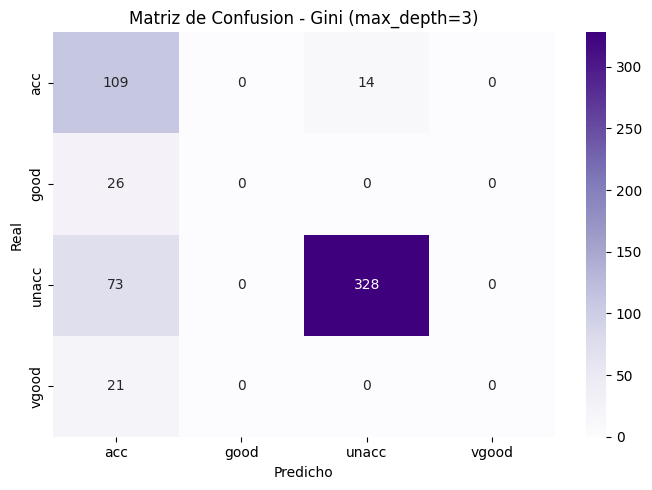

In [34]:
# Obtenemos los nombres de clase originales desde el LabelEncoder
class_names = label_encoders['class'].classes_
cm = confusion_matrix(y_test, y_pred_gini)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Matriz de Confusion - Gini (max_depth=3)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

In [35]:
# Reporte detallado con precision, recall y F1 por clase
print(classification_report(y_test, y_pred_gini, target_names=class_names))

              precision    recall  f1-score   support

         acc       0.48      0.89      0.62       123
        good       0.00      0.00      0.00        26
       unacc       0.96      0.82      0.88       401
       vgood       0.00      0.00      0.00        21

    accuracy                           0.77       571
   macro avg       0.36      0.43      0.38       571
weighted avg       0.78      0.77      0.75       571



### Pregunta 9: Interpretación de la Matriz de Confusión
¿Qué clase tiene el mejor recall (sensibilidad) según el reporte?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** A

## Parte 9: Visualización del Árbol de Decisión

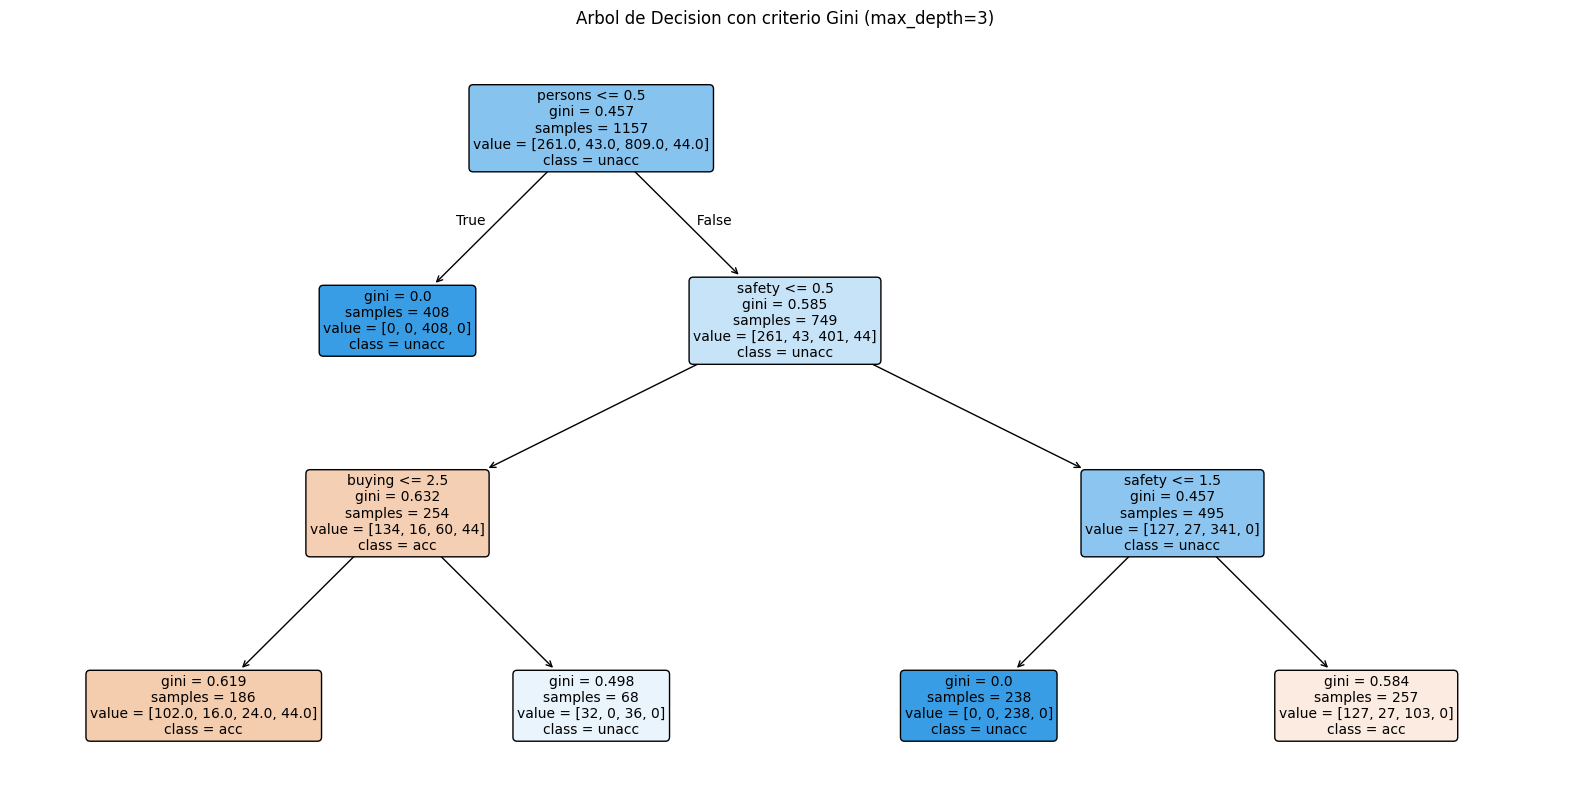

In [37]:
#Aarbol de decision con criterio Gini
plt.figure(figsize=(20, 10))
plot_tree(
    clf_gini,
    feature_names=list(X.columns),
    class_names=list(class_names),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Arbol de Decision con criterio Gini (max_depth=3)')
plt.show()

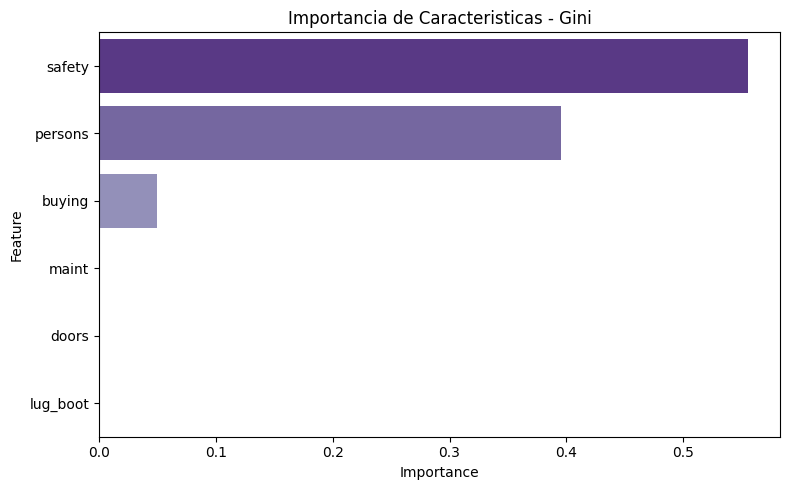

    Feature  Importance
5    safety    0.555158
3   persons    0.395106
0    buying    0.049736
1     maint    0.000000
2     doors    0.000000
4  lug_boot    0.000000


In [39]:
# Importancia de cada caracteristica segun el modelo Gini
importancias = pd.DataFrame({
    'Feature'    : X.columns,
    'Importance' : clf_gini.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importancias, palette='Purples_r')
plt.title('Importancia de Caracteristicas - Gini')
plt.tight_layout()
plt.show()
print(importancias)

### Pregunta 10: Característica más Importante
¿Cuál es la característica más importante según el modelo con Gini?

A) buying (precio de compra)  
B) maint (mantenimiento)  
C) safety (seguridad)  
D) persons (capacidad de personas)  

**Su Respuesta:** C

## Parte 10: Experimentación con Hiperparámetros

In [40]:
depths = [1, 2, 3, 5, 7, 10, None]
resultados_depth = []

# Entrenamos un modelo por cada profundidad y registramos los resultados
for d in depths:
    clf_d = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=19)
    clf_d.fit(X_train, y_train)
    resultados_depth.append({
        'max_depth'      : str(d),
        'Precision Train': accuracy_score(y_train, clf_d.predict(X_train)),
        'Precision Test' : accuracy_score(y_test,  clf_d.predict(X_test)),
        'Profundidad'    : clf_d.get_depth(),
        'Hojas'          : clf_d.get_n_leaves()
    })

df_depths = pd.DataFrame(resultados_depth)
print(df_depths)

  max_depth  Precision Train  Precision Test  Profundidad  Hojas
0         1         0.699222        0.702277            1      2
1         2         0.763181        0.781086            2      3
2         3         0.787381        0.765324            3      5
3         5         0.883319        0.851138            5     13
4         7         0.929127        0.912434            7     29
5        10         0.983578        0.961471           10     65
6      None         1.000000        0.973730           13     82


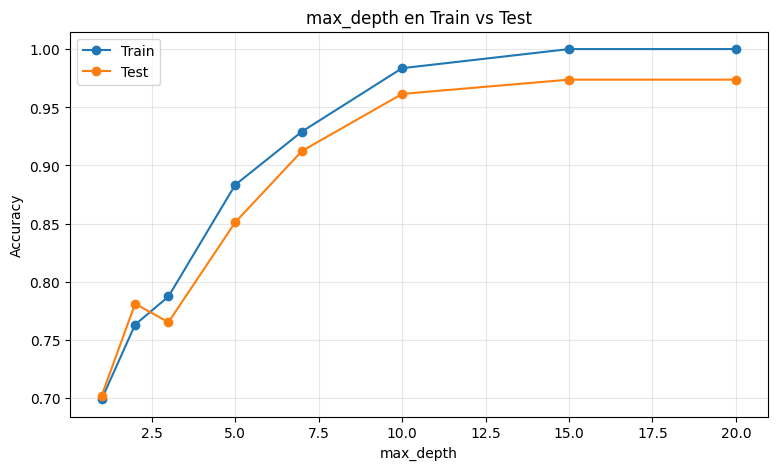

In [42]:
depths_plot  = [1, 2, 3, 5, 7, 10, 15, 20]
train_scores = []
test_scores  = []

# Calculamos precision en train y test para cada profundidad
for d in depths_plot:
    clf_d = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=19)
    clf_d.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf_d.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  clf_d.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths_plot, train_scores, marker='o', label='Train')
plt.plot(depths_plot, test_scores,  marker='o', label='Test')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('max_depth en Train vs Test')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Pregunta 11: Efecto de max_depth
¿Qué ocurre cuando max_depth es muy alto (por ejemplo, 20 o None)?

A) El modelo mejora en test y train  
B) El modelo empeora en test y train  
C) Train accuracy sube pero test accuracy puede bajar (sobreajuste)  
D) No hay efecto significativo  

**Su Respuesta:** C

In [43]:
min_samples_list = [2, 5, 10, 20, 50]
resultados_mss   = []

# Variamos min_samples_split sin limitar profundidad para ver su efecto
for mss in min_samples_list:
    clf_mss = DecisionTreeClassifier(criterion='gini', min_samples_split=mss, random_state=19)
    clf_mss.fit(X_train, y_train)
    resultados_mss.append({
        'min_samples_split': mss,
        'Precision Train'  : accuracy_score(y_train, clf_mss.predict(X_train)),
        'Precision Test'   : accuracy_score(y_test,  clf_mss.predict(X_test)),
        'Profundidad'      : clf_mss.get_depth(),
        'Hojas'            : clf_mss.get_n_leaves()
    })

df_mss = pd.DataFrame(resultados_mss)
print(df_mss)

   min_samples_split  Precision Train  Precision Test  Profundidad  Hojas
0                  2         1.000000        0.973730           13     82
1                  5         0.987035        0.968476           12     67
2                 10         0.968885        0.938704           11     50
3                 20         0.956785        0.933450           10     39
4                 50         0.894555        0.854641            8     18


### Pregunta 12: min_samples_split
¿Qué controla el parámetro min_samples_split?

A) El número máximo de hojas  
B) El número mínimo de muestras para dividir un nodo  
C) La profundidad máxima del árbol  
D) El número de características a considerar  

**Su Respuesta:** B

## Parte 11: Modelo Final Optimizado

In [44]:
# Modelo final usando los mejores hiperparametros observados en los experimentos
clf_final = DecisionTreeClassifier(
    criterion='gini',
    max_depth=7,
    min_samples_split=5,
    random_state=19
)
clf_final.fit(X_train, y_train)
y_pred_final = clf_final.predict(X_test)
acc_final_train = accuracy_score(y_train, clf_final.predict(X_train))
acc_final_test  = accuracy_score(y_test,  y_pred_final)

print(f'Precision en entrenamiento: {acc_final_train:.4f}')
print(f'Precision en prueba       : {acc_final_test:.4f}')
print(f'Profundidad del arbol     : {clf_final.get_depth()}')
print(f'Numero de hojas           : {clf_final.get_n_leaves()}')

Precision en entrenamiento: 0.9291
Precision en prueba       : 0.9124
Profundidad del arbol     : 7
Numero de hojas           : 29


In [45]:
# Reporte de clasificacion del modelo optimizado
print(classification_report(y_test, y_pred_final, target_names=class_names))

              precision    recall  f1-score   support

         acc       0.74      0.96      0.84       123
        good       0.00      0.00      0.00        26
       unacc       0.98      0.96      0.97       401
       vgood       0.87      0.95      0.91        21

    accuracy                           0.91       571
   macro avg       0.65      0.72      0.68       571
weighted avg       0.88      0.91      0.89       571



### Pregunta 13: Precisión del Modelo Optimizado
¿Cuál es la precisión aproximada del modelo final optimizado?

A) 70-75%  
B) 75-85%  
C) 85-95%  
D) 95-100%  

**Su Respuesta:** C

## Parte 12: Resumen y Conclusiones

### Pregunta 14: Ventajas de los Árboles de Decisión
¿Cuál es una ventaja principal de los árboles de decisión?

A) Siempre tienen la mejor precisión  
B) Son fáciles de interpretar y visualizar  
C) No requieren ningún preprocesamiento  
D) Nunca sobreajustan  

**Su Respuesta:** B

### Pregunta 15: Desventajas de los Árboles de Decisión
¿Cuál es una desventaja de los árboles de decisión?

A) No pueden manejar datos categóricos  
B) Son muy lentos de entrenar  
C) Tienden a sobreajustar si no se limita su complejidad  
D) No proporcionan probabilidades de predicción  

**Su Respuesta:** C